/var/folders/xt/zxpvbvsx2zb75gd2395zm9000000gn/T/ipykernel_48738/1385588447.py:61: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cx_geo = city_shp_geo.geometry.centroid.x
/var/folders/xt/zxpvbvsx2zb75gd2395zm9000000gn/T/ipykernel_48738/1385588447.py:62: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cy_geo = city_shp_geo.geometry.centroid.y


Drawing 2020 flow map...
Drawing 2060 flow map...
Computing distance trends (all cities)...
2020 | region=None | valid origins: 357
2030 | region=None | valid origins: 356
2040 | region=None | valid origins: 356
2050 | region=None | valid origins: 357
2060 | region=None | valid origins: 356
Computing distance trends (West)...
2020 | region=West | valid origins: 90
2030 | region=West | valid origins: 89
2040 | region=West | valid origins: 89
2050 | region=West | valid origins: 90
2060 | region=West | valid origins: 90
Computing distance trends (East)...
2020 | region=East | valid origins: 267
2030 | region=East | valid origins: 267
2040 | region=East | valid origins: 267
2050 | region=East | valid origins: 267
2060 | region=East | valid origins: 266
Drawing 2020 vs 2060 density comparison...


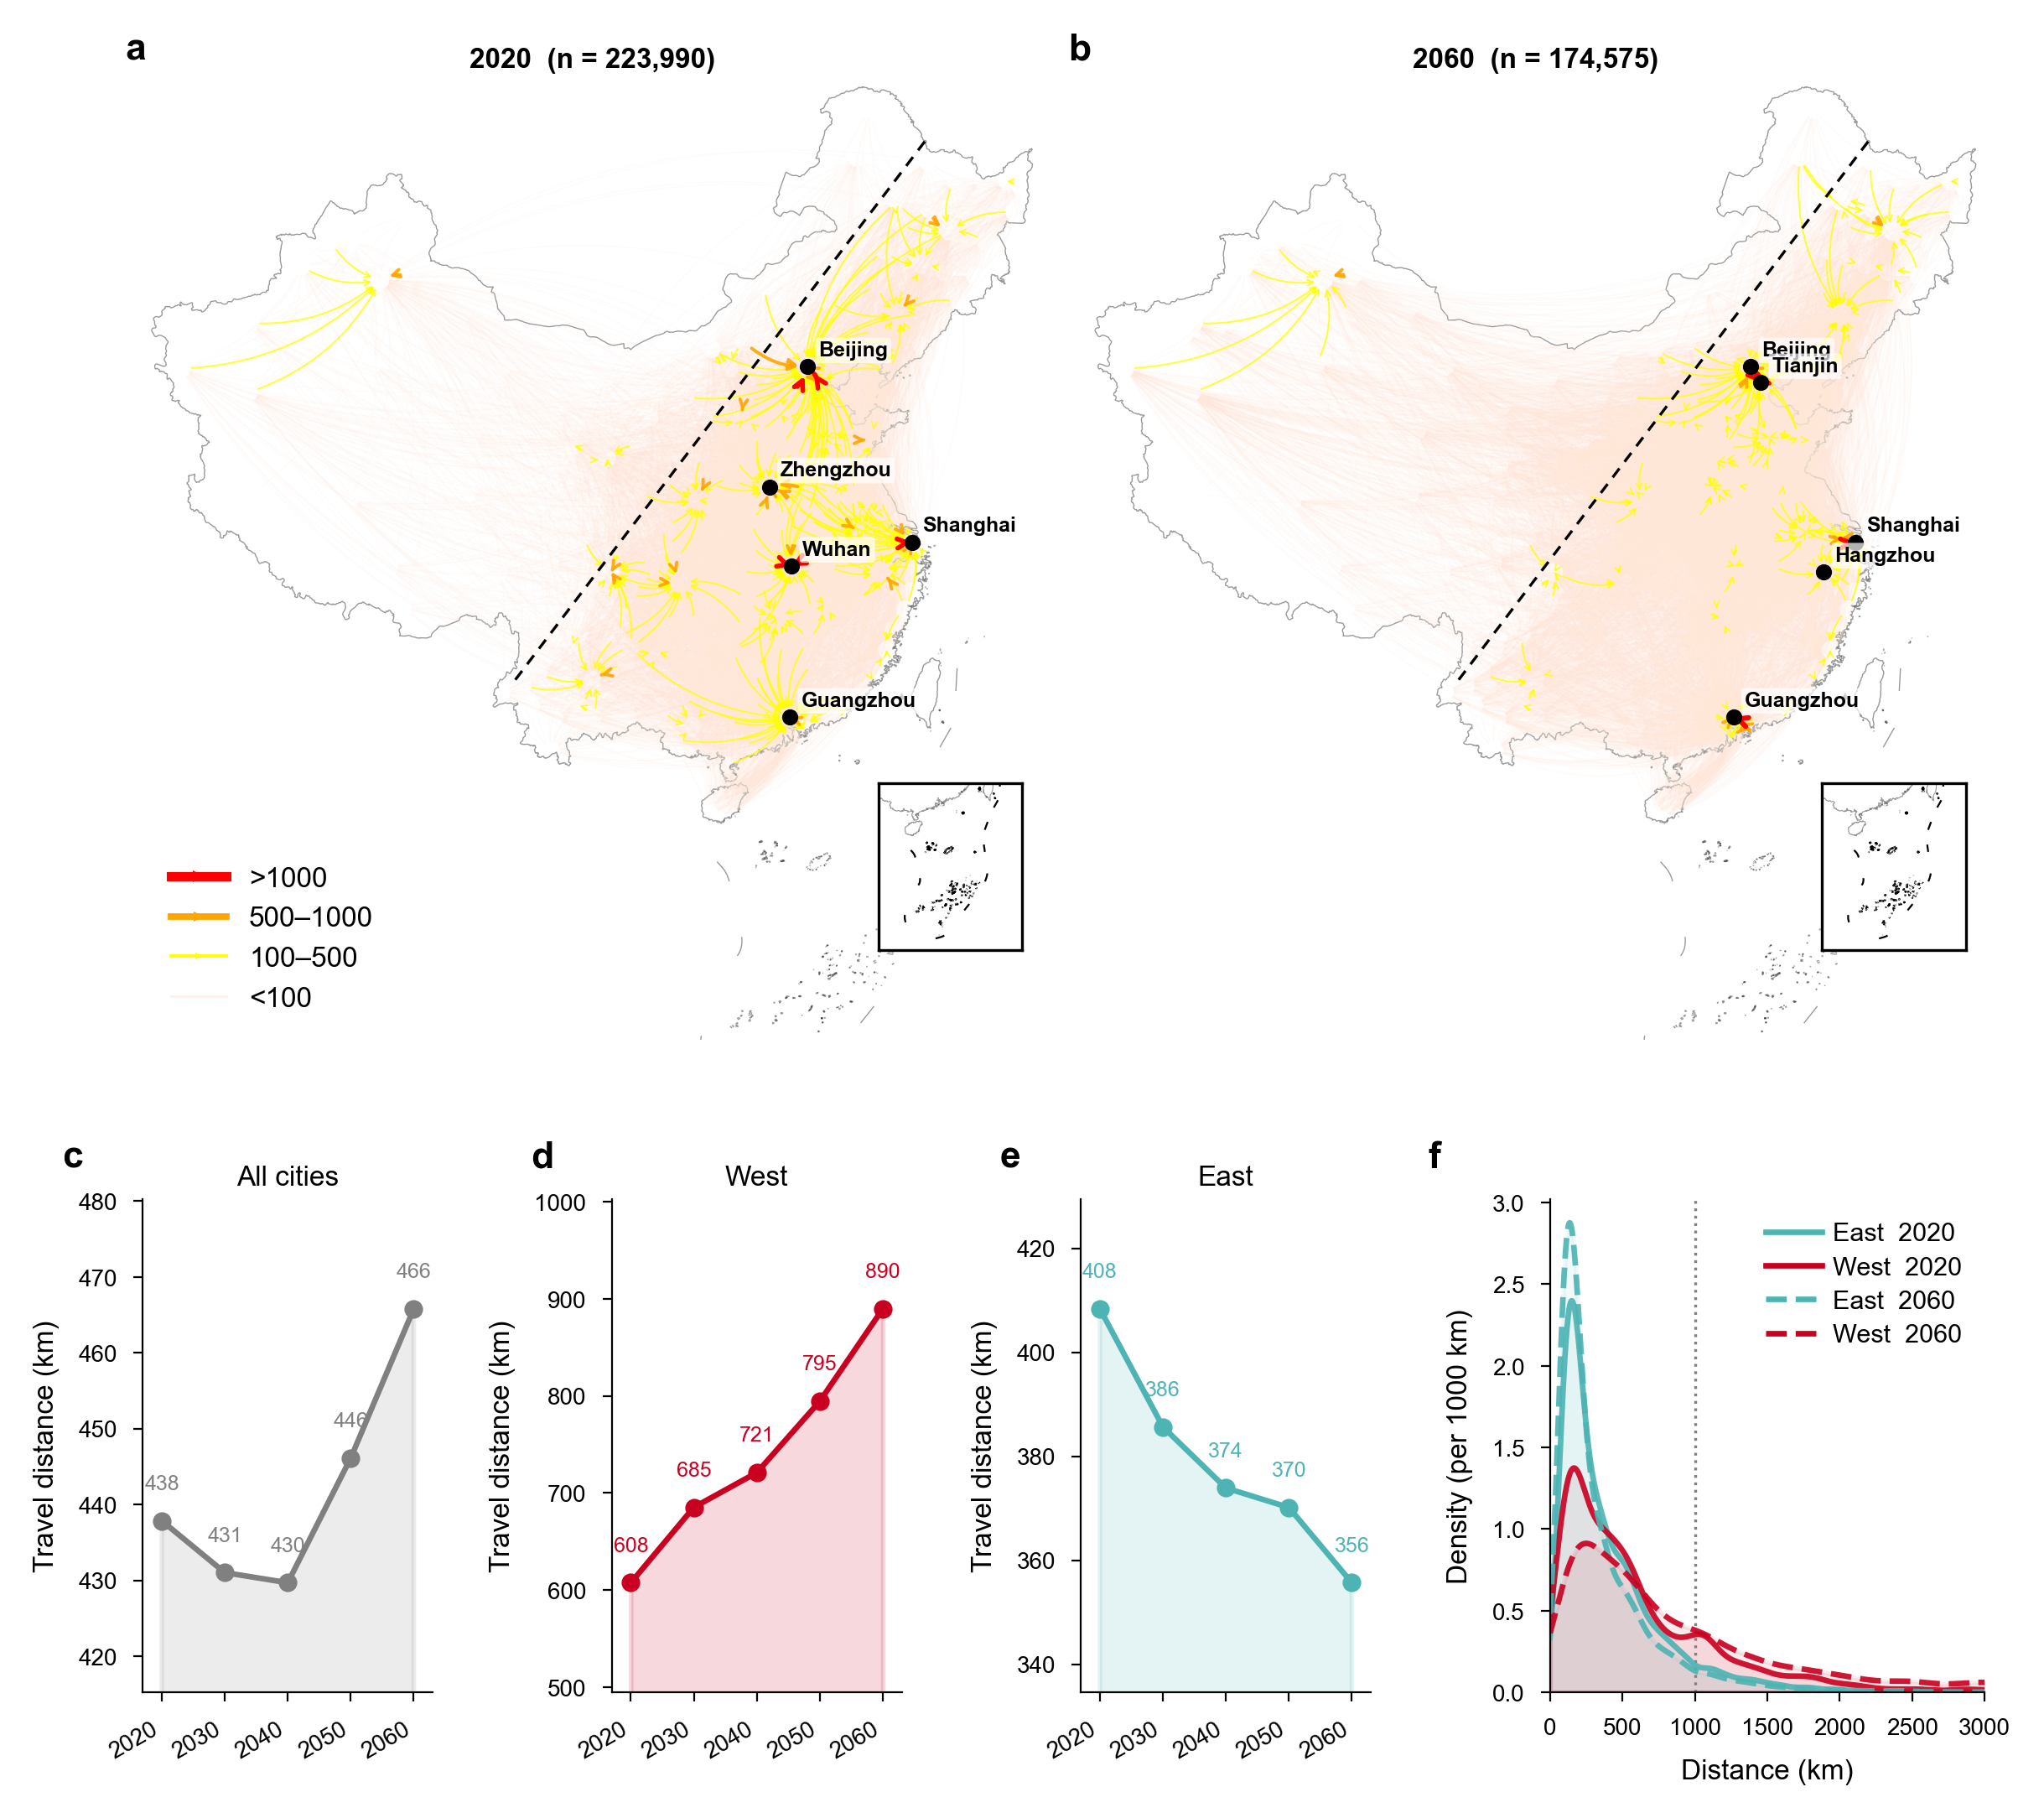

✓ Saved → /Users/shirley/Desktop/plots_V2/Fig2_Flow_full_truncated.png


In [3]:
# =============================================================================
# Fig2: Row 1 flow map (2020 vs 2060) + Row 2 avg distance trends & density plot
# Row 2: c=national trend d=west trend e=east trend f=density plot (pooled)
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec
from shapely.geometry import box as shapely_box
from pyproj import Transformer
from scipy.stats import gaussian_kde

# ── 1. Paths ──────────────────────────────────────────────────────────────────
DATA_DIR  = Path("/Volumes/UCL/论文工作/空气污染/cross_flow_truncated/averaged_results/flow_avg")
DIST_PATH = Path("/Volumes/UCL/论文工作/空气污染/city_distance/rail_distance_matrix.csv")
SHP_PATH  = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/city_shp/shi_en.shp")
CHINA_SHP = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国底图-中图社审过版本/中国底图/中国面.shp")
CHINA_SHP2= Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国国界线/九段线/九段线和群岛.shp")
OUTFILE   = Path("/Users/shirley/Desktop/plots_V2/Fig2_Flow_full_truncated.png")

SCENARIO  = "earlypeak_NZ_CL"
PROJ_STR  = "+proj=aea +lat_1=25 +lat_2=47 +lat_0=0 +lon_0=105"
YEARS     = [2020, 2030, 2040, 2050, 2060]

# ── 2. Flow categories ────────────────────────────────────────────────────────
FLOW_CATS = [
    (">1000",    1000, np.inf, "red",      1.0,  1.0,  5),
    ("500–1000",  500,  1000,  "orange",   0.9,  0.7,  4),
    ("100–500",   100,   500,  "yellow",   0.8,  0.35, 3),
    ("<100",        1,   100,  "#FEE7D7",  0.1,  0.25, 0),
]

# ── 3. Spatial data ───────────────────────────────────────────────────────────
china_border = gpd.read_file(CHINA_SHP).to_crs(PROJ_STR)
jiudanline   = gpd.read_file(CHINA_SHP2).to_crs(PROJ_STR)
city_shp     = gpd.read_file(SHP_PATH).to_crs(PROJ_STR)

city_shp["geometry"]  = city_shp.geometry.representative_point()
city_shp["cx"]        = city_shp.geometry.x
city_shp["cy"]        = city_shp.geometry.y
city_shp["city_name"] = city_shp["English"].str.strip()

city_pts = (
    city_shp
    .drop_duplicates(subset="city_name", keep="first")
    .set_index("city_name")[["cx", "cy"]]
    .to_dict("index")
)

HHY = {"lon": [127.5, 98.5], "lat": [50.2, 25.0]}

def hhy_lon_at_lat(lat):
    t = (lat - HHY["lat"][1]) / (HHY["lat"][0] - HHY["lat"][1])
    return HHY["lon"][1] + t * (HHY["lon"][0] - HHY["lon"][1])

city_shp_geo = gpd.read_file(SHP_PATH)
cx_geo = city_shp_geo.geometry.centroid.x
cy_geo = city_shp_geo.geometry.centroid.y
city_shp_geo["region"] = np.where(
    cx_geo > hhy_lon_at_lat(cy_geo), "East", "West"
)
region_map = (
    city_shp_geo[["English", "region"]]
    .rename(columns={"English": "city"})
    .drop_duplicates(subset="city")
    .set_index("city")["region"]
    .to_dict()
)

_tf = Transformer.from_crs("EPSG:4326", PROJ_STR, always_xy=True)
_HHY_X, _HHY_Y = _tf.transform([127.5, 98.5], [50.2, 25.0])

_NANHAI_BOUNDS = (
    gpd.GeoDataFrame(geometry=[shapely_box(105, 2, 122, 24)], crs="EPSG:4326")
    .to_crs(PROJ_STR).total_bounds
)

xmin, ymin, xmax, ymax = china_border.total_bounds
pad_x = (xmax - xmin) * 0.01
pad_y = (ymax - ymin) * 0.01

# ── 4. Distance matrix ────────────────────────────────────────────────────────
dist_df = pd.read_csv(DIST_PATH, index_col=0)
dist_df.index   = dist_df.index.str.strip()
dist_df.columns = dist_df.columns.str.strip()

# ── 5. Computation helpers ────────────────────────────────────────────────────
def load_matrix(year):
    path = DATA_DIR / f"flow_patientnum_avg_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path, index_col=0)
    df.index   = df.index.str.strip()
    df.columns = df.columns.str.strip()
    df = df[df.index.notna()]
    df = df.loc[~df.index.isin(["total"]),
                ~df.columns.isin(["total"])]
    np.fill_diagonal(df.values, 0)
    valid  = set(city_pts.keys())
    cities = [c for c in df.index if c in valid]
    return df.loc[cities, [c for c in df.columns if c in valid]]


def compute_all_edges(df):
    edges = []
    for ci in df.index:
        for cj in df.columns:
            if ci == cj: continue
            try:
                flow = float(df.loc[ci, cj])
            except KeyError:
                continue
            if np.isnan(flow) or flow <= 1: continue
            edges.append({"ori": ci, "dst": cj, "flow": flow})
    if not edges:
        return pd.DataFrame()
    edge_df = pd.DataFrame(edges)
    def get_cat(val):
        for label, lo, hi, *_ in FLOW_CATS:
            if lo < val <= hi: return label
        return None
    edge_df["flow_cat"] = edge_df["flow"].apply(get_cat)
    return edge_df.dropna(subset=["flow_cat"])


def compute_weighted_avg_dist(year, region=None):
    df = load_matrix(year)
    total_flow, total_weighted = 0.0, 0.0
    valid_origins = set()
    for ci in df.index:
        if region is not None and region_map.get(ci, "East") != region:
            continue
        for cj in df.columns:
            if ci == cj: continue
            try:
                flow = float(df.loc[ci, cj])
                dist = float(dist_df.loc[ci, cj])
            except (KeyError, ValueError):
                continue
            if np.isnan(flow) or flow <= 1: continue
            if np.isnan(dist) or dist <= 0: continue
            valid_origins.add(ci)
            total_flow     += flow
            total_weighted += flow * dist
    print(f"{year} | region={region} | valid origins: {len(valid_origins)}")
    return total_weighted / total_flow if total_flow > 0 else np.nan


def compute_flow_dist_pairs(year):
    """Single-year OD pairs: (dist, flow, region)"""
    df      = load_matrix(year)
    records = []
    for ci in df.index:
        region_ci = region_map.get(ci, "East")
        for cj in df.columns:
            if ci == cj: continue
            try:
                flow = float(df.loc[ci, cj])
                dist = float(dist_df.loc[ci, cj])
            except (KeyError, ValueError):
                continue
            if np.isnan(flow) or flow <= 1: continue
            if np.isnan(dist) or dist <= 0: continue
            records.append({"dist": dist, "flow": flow, "region": region_ci})
    return pd.DataFrame(records)

# ── 6. Flow map plotting ──────────────────────────────────────────────────────
def draw_arrows_on_ax(ax, edge_df, lw_scale=1.0, ms_scale=1.0):
    for label, lo, hi, color, alpha, lw, ms in reversed(FLOW_CATS):
        sub = edge_df[edge_df["flow_cat"] == label]
        for _, row in sub.iterrows():
            try:
                ox = city_pts[row["ori"]]["cx"]
                oy = city_pts[row["ori"]]["cy"]
                dx = city_pts[row["dst"]]["cx"]
                dy = city_pts[row["dst"]]["cy"]
            except KeyError:
                continue
            if ms == 0:
                ax.annotate("", xy=(dx, dy), xytext=(ox, oy),
                            arrowprops=dict(
                                arrowstyle="-", color=color,
                                lw=lw*lw_scale, alpha=alpha,
                                connectionstyle="arc3,rad=0.2"),
                            zorder=2, annotation_clip=True)
            else:
                ax.annotate("", xy=(dx, dy), xytext=(ox, oy),
                            arrowprops=dict(
                                arrowstyle="->", color=color,
                                lw=lw*lw_scale, alpha=alpha,
                                mutation_scale=ms*ms_scale,
                                connectionstyle="arc3,rad=0.2"),
                            zorder=3, annotation_clip=True)


def draw_flow_map(ax_main, year, tag):
    df      = load_matrix(year)
    edge_df = compute_all_edges(df)

    china_border.plot(ax=ax_main, facecolor="white", edgecolor="black",
                      linewidth=0.25, alpha=0.4)
    jiudanline.plot(ax=ax_main, facecolor="white", edgecolor="black",
                    linewidth=0.25, alpha=0.4)

    if not edge_df.empty:
        draw_arrows_on_ax(ax_main, edge_df)

    ax_main.plot(_HHY_X, _HHY_Y, color="black", lw=0.6,
                 linestyle="--", dashes=(4, 3), zorder=5)

    inflow = df.sum(axis=0)
    top5   = inflow.nlargest(5)

    LABEL_OFFSET = {}
    DEFAULT_OFFSET = (60000, 60000)

    for city, val in top5.items():
        if city not in city_pts:
            continue
        cx = city_pts[city]["cx"]
        cy = city_pts[city]["cy"]
        ax_main.scatter(cx, cy, s=12, color="black", zorder=6, linewidths=0)
        ox, oy = LABEL_OFFSET.get(city, DEFAULT_OFFSET)
        ax_main.annotate(
            city,
            xy=(cx, cy), xytext=(cx + ox, cy + oy),
            fontsize=4.5, color="black", fontweight="bold", zorder=7,
            arrowprops=dict(arrowstyle="-", color="black", lw=0.4),
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                      edgecolor="none", alpha=0.7),
        )

    ax_main.set_xlim(xmin - pad_x, xmax + pad_x)
    ax_main.set_ylim(ymin + (ymax - ymin)*0.05, ymax + pad_y)
    ax_main.set_axis_off()
    ax_main.text(-0.02, 1.01, tag, transform=ax_main.transAxes,
                 fontsize=8, fontweight="bold", va="bottom")
    
    total_n = int(round(df.values.sum())) 
    ax_main.set_title(f"{year}  (n = {total_n:,})", 
                      fontsize=6, fontweight="bold", loc="center", pad=2)


def add_flow_legend(ax):
    handles = []
    for label, lo, hi, color, alpha, lw, ms in FLOW_CATS:
        if ms == 0:
            handles.append(mlines.Line2D(
                [], [], color=color, alpha=min(alpha+0.5, 1.0),
                linewidth=lw*2, label=label))
        else:
            handles.append(mlines.Line2D(
                [], [], color=color, alpha=min(alpha+0.2, 1.0),
                linewidth=lw*2, marker=">", markersize=ms*0.5,
                markerfacecolor=color, markeredgewidth=0, label=label))
    ax.legend(handles=handles, fontsize=6, frameon=False,
              loc="lower left", handlelength=2.0,
              labelspacing=0.5, borderpad=0.5)

# ── 7. Row 2 plotting ─────────────────────────────────────────────────────────
def draw_avg_dist_trend(ax, region, title, color, tag):
    avg_dists = [compute_weighted_avg_dist(y, region) for y in YEARS]
    valid     = [d for d in avg_dists if not np.isnan(d)]
    rng       = (max(valid) - min(valid)) if len(valid) > 1 else 50

    ax.plot(YEARS, avg_dists, color=color, lw=1.2,
            marker="o", ms=3, zorder=3)
    ax.fill_between(YEARS, avg_dists, alpha=0.15, color=color, zorder=2)

    for y, d in zip(YEARS, avg_dists):
        if not np.isnan(d):
            ax.text(y, d + rng * 0.1, f"{d:.0f}",
                    ha="center", va="bottom", fontsize=4.5, color=color)

    if valid:
        y_pad = (max(valid) - min(valid)) * 0.4
        ax.set_ylim(min(valid) - y_pad, max(valid) + y_pad)

    ax.set_xlim(2017, 2063)
    ax.set_xticks(YEARS)
    ax.set_xticklabels([str(y) for y in YEARS],
                       rotation=30, ha="right", fontsize=5)
    ax.set_ylabel("Travel distance (km)", fontsize=6)
    ax.set_title(title, fontsize=6, pad=3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["bottom", "left"]].set_linewidth(0.4)
    ax.tick_params(width=0.4, length=2, labelsize=5)
    ax.text(-0.28, 1.05, tag, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="bottom")


def draw_density_2020_2060(ax, tag):
    """
    Compare 2020 vs 2060 distance distributions.
    Colour = region: East #4db3b3 / West #ca0020  (unchanged)
    Linestyle = year: 2020 solid / 2060 dashed
    """
    REGION_COLORS = {
        "East": "#4db3b3",
        "West": "#ca0020",
    }
    YEAR_LS = {
        2020: "-",    # solid
        2060: "--",   # dashed
    }

    x_grid  = np.linspace(0, 3000, 1000)
    handles = []

    for year, ls in YEAR_LS.items():
        df_y = compute_flow_dist_pairs(year)

        for region, color in REGION_COLORS.items():
            sub = df_y[df_y["region"] == region]
            if len(sub) < 2:
                continue

            kde     = gaussian_kde(sub["dist"].values,
                                   weights=sub["flow"].values,
                                   bw_method=0.15)
            density = kde(x_grid) * 1000

            ax.plot(x_grid, density,
                    color=color, ls=ls, lw=1.2, alpha=0.9)
            ax.fill_between(x_grid, density,
                            color=color, alpha=0.08)

            handles.append(
                mlines.Line2D([], [], color=color, ls=ls, lw=1.2,
                              label=f"{region}  {year}")
            )

    ax.axvline(1000, color="grey", lw=0.6, ls=":", zorder=1)

    ax.set_xlabel("Distance (km)", fontsize=6)
    ax.set_ylabel("Density (per 1000 km)", fontsize=6)
    ax.set_xlim(0, 3000)
    ax.set_ylim(bottom=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["bottom", "left"]].set_linewidth(0.4)
    ax.tick_params(width=0.4, length=2, labelsize=5)
    ax.text(-0.28, 1.05, tag, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="bottom")

    ax.legend(handles=handles, fontsize=5.5, frameon=False,
              loc="upper right", labelspacing=0.4,
              handlelength=2.2, handletextpad=0.4)


# ── 8. Layout ─────────────────────────────────────────────────────────────────
plt.rcParams.update({"font.family": "Arial", "font.size": 6})

W_IN, H_IN, DPI = 18/2.54, 16/2.54, 400

fig = plt.figure(figsize=(W_IN, H_IN), dpi=DPI)

gs_outer = GridSpec(2, 1, figure=fig,
                    height_ratios=[2, 1],
                    hspace=0.20)

gs_row1 = gs_outer[0].subgridspec(1, 2, wspace=0.05)
ax_map1 = fig.add_subplot(gs_row1[0, 0])
ax_map2 = fig.add_subplot(gs_row1[0, 1])

gs_row2 = gs_outer[1].subgridspec(
    1, 4,
    width_ratios=[1, 1, 1, 1.5],
    wspace=0.55,
)
ax_d1 = fig.add_subplot(gs_row2[0, 0])
ax_d2 = fig.add_subplot(gs_row2[0, 1])
ax_d3 = fig.add_subplot(gs_row2[0, 2])
ax_d4 = fig.add_subplot(gs_row2[0, 3])

# ── 9. Visualization ──────────────────────────────────────────────────────────
print("Drawing 2020 flow map...")
draw_flow_map(ax_map1, 2020, "a")

print("Drawing 2060 flow map...")
draw_flow_map(ax_map2, 2060, "b")

add_flow_legend(ax_map1)

fig.canvas.draw()

BOX_W_RATIO   = 0.16
BOX_H_RATIO   = 0.2
OFFSET_RIGHT  = 0.008
OFFSET_BOTTOM = 0.08

nx0, ny0, nx1, ny1 = _NANHAI_BOUNDS

for ax_main in [ax_map1, ax_map2]:
    pos   = ax_main.get_position()
    box_w = pos.width  * BOX_W_RATIO
    box_h = pos.height * BOX_H_RATIO
    box_x = pos.x1 - box_w - OFFSET_RIGHT
    box_y = pos.y0 + pos.height * OFFSET_BOTTOM

    ax_nh = fig.add_axes([box_x, box_y, box_w, box_h])
    ax_nh.set_facecolor("white")
    china_border.plot(ax=ax_nh, facecolor="white", edgecolor="black",
                      linewidth=0.2, alpha=0.4)
    jiudanline.plot(ax=ax_nh, edgecolor="black", linewidth=0.4)
    ax_nh.set_xlim(nx0, nx1)
    ax_nh.set_ylim(ny0, ny1)
    ax_nh.tick_params(left=False, bottom=False,
                      labelleft=False, labelbottom=False)
    for sp in ax_nh.spines.values():
        sp.set_linewidth(0.6)
        sp.set_color("black")

print("Computing distance trends (all cities)...")
draw_avg_dist_trend(ax_d1, region=None,
                    title="All cities", color="grey", tag="c")

print("Computing distance trends (West)...")
draw_avg_dist_trend(ax_d2, region="West",
                    title="West", color="#ca0020", tag="d")

print("Computing distance trends (East)...")
draw_avg_dist_trend(ax_d3, region="East",
                    title="East", color="#4db3b3", tag="e")

print("Drawing 2020 vs 2060 density comparison...")
draw_density_2020_2060(ax_d4, tag="f")

# ── 10. Save ──────────────────────────────────────────────────────────────────
OUTFILE.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTFILE, dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show(fig)
print(f"✓ Saved → {OUTFILE}")